In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Load datasets
teams = pd.read_csv("teams_data.csv", encoding="latin1")
players = pd.read_csv("players_data_updated.csv", encoding="latin1")
matches = pd.read_csv("ipl_matches_data.csv", encoding="latin1")
data = pd.read_csv("ball_by_ball_data.csv")

In [3]:
# View first few rows of each dataset
print("Teams Data:")
print(teams.head(), "\n")

print("Players Data:")
print(players.head(), "\n")

print("Matches Data:")
print(matches.head(), "\n")

print("Ball-by-Ball Data:")
print(data.head(), "\n")

# Optional: check column names for each table
print("Teams Columns:", teams.columns.tolist())
print("Players Columns:", players.columns.tolist())
print("Matches Columns:", matches.columns.tolist())
print("Ball-by-Ball Columns:", data.columns.tolist())

Teams Data:
   team_id                    team_name team_name_short  \
0        1  Royal Challengers Bangalore             RCB   
1        2          Sunrisers Hyderabad             SRH   
2        3               Mumbai Indians              MI   
3        4       Rising Pune Supergiant             RPS   
4        5                Gujarat Lions              GL   

                                           image_url  
0  https://documents.iplt20.com/ipl/RCB/Logos/Log...  
1  https://documents.iplt20.com/ipl/SRH/Logos/Log...  
2  https://documents.iplt20.com/ipl/MI/Logos/Logo...  
3  https://ipl-stats-sports-mechanic.s3.ap-south-...  
4  https://ipl-stats-sports-mechanic.s3.ap-south-...   

Players Data:
   player_id  player_name       bat_style            bowl_style field_pos  \
0       6730  Mohsin Khan   Left hand Bat  Left arm Medium fast       NaN   
1         22  Rashid Khan  Right hand Bat       Legbreak Googly             
2        590     K Rabada   Left hand Bat        Right a

Step 1: Data Preprocessing & Cleaning

In [4]:
# Handle missing values
teams = teams.dropna()
players = players.fillna("Unknown")
matches['match_date'] = pd.to_datetime(matches['match_date'], format='%d-%m-%Y', errors='coerce')
data = data.fillna(0)

# Ensure consistent naming
matches['team1'] = matches['team1'].str.strip()
matches['team2'] = matches['team2'].str.strip()
matches['match_winner'] = matches['match_winner'].str.strip()

# Convert numeric columns
matches['win_by_runs'] = pd.to_numeric(matches['win_by_runs'], errors='coerce').fillna(0)
matches['win_by_wickets'] = pd.to_numeric(matches['win_by_wickets'], errors='coerce').fillna(0)

Step 2: Exploratory Data Analysis (EDA)

1. Team Wins Distribution (Pie Chart)

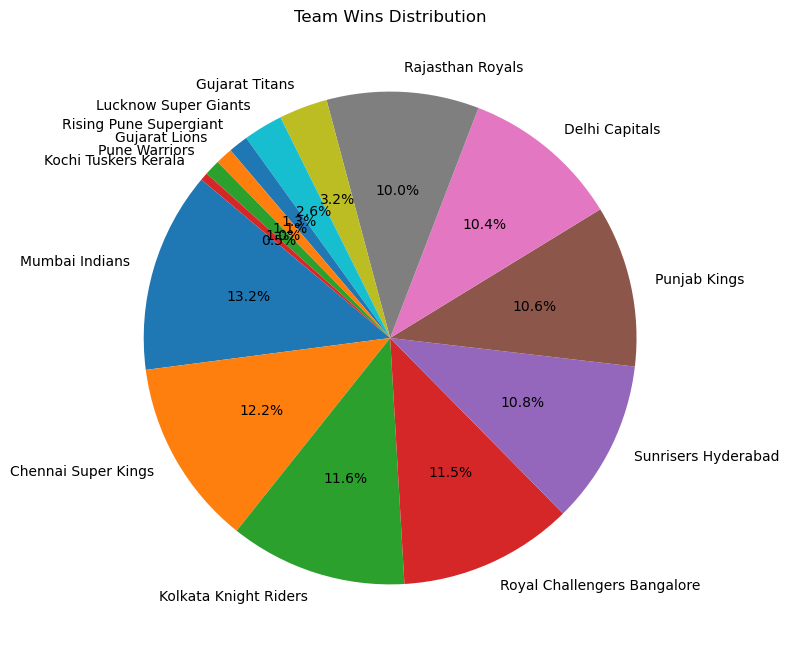

In [5]:
team_wins = matches['match_winner'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(team_wins, labels=team_wins.index, autopct='%1.1f%%', startangle=140)
plt.title("Team Wins Distribution")
plt.show()

2. Top Players by Player of the Match (Bar/Worm Plot)

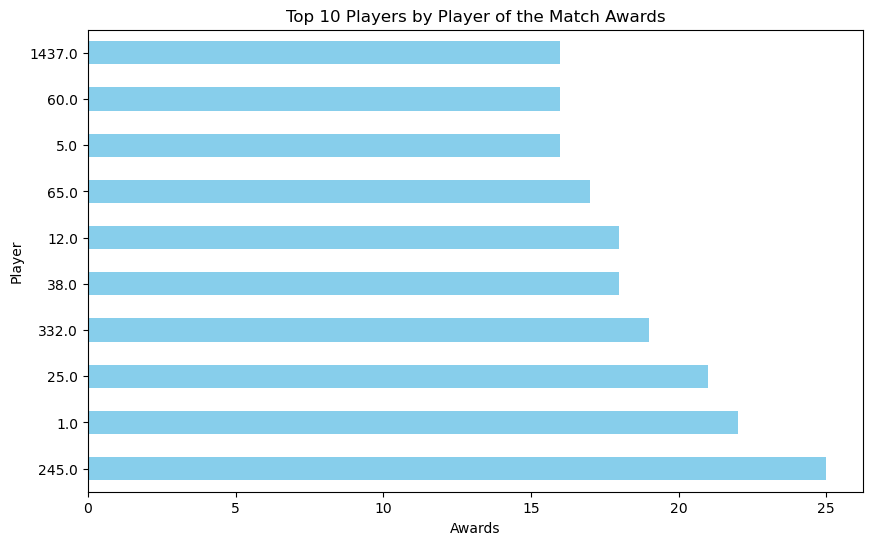

In [6]:
top_players = matches['player_of_match'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_players.plot(kind='barh', color='skyblue')
plt.title("Top 10 Players by Player of the Match Awards")
plt.xlabel("Awards")
plt.ylabel("Player")
plt.show()

3. Venue Analysis (Manhattan-style comparison)

C:\Users\bhara\AppData\Local\Temp\ipykernel_23556\1224530462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venue_wins.index, y=venue_wins.values, palette="viridis")


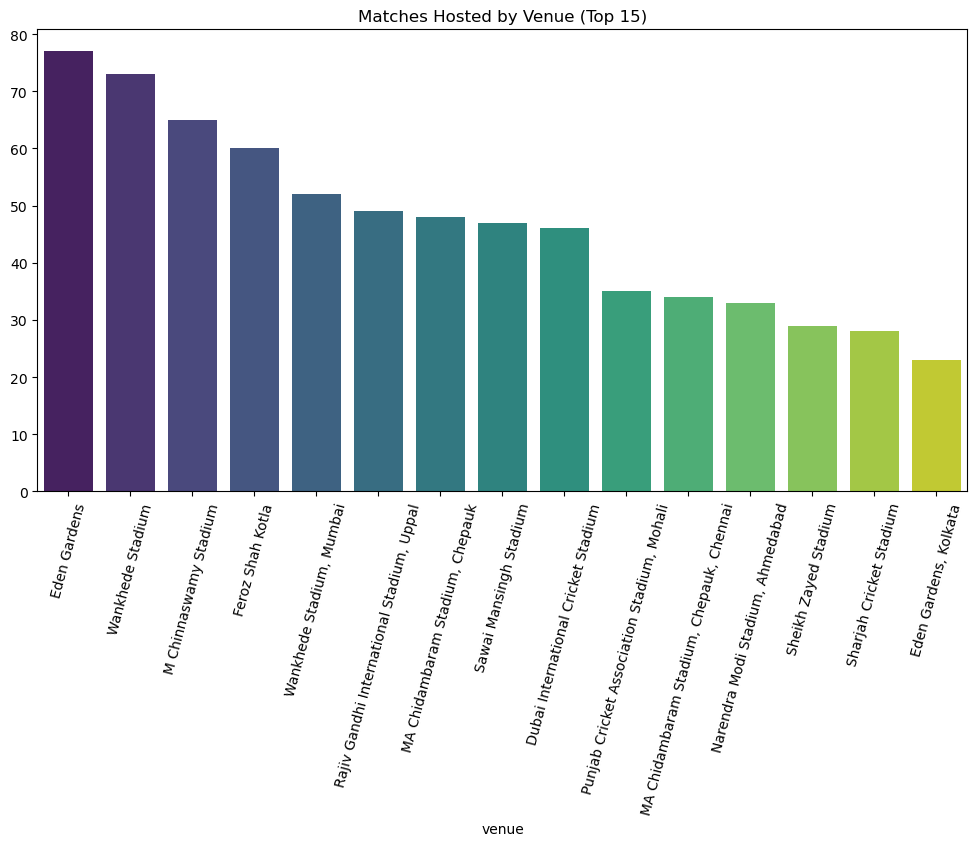

In [7]:
venue_wins = matches['venue'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=venue_wins.index, y=venue_wins.values, palette="viridis")
plt.xticks(rotation=75)
plt.title("Matches Hosted by Venue (Top 15)")
plt.show()

4. Toss Decision vs Match Outcome

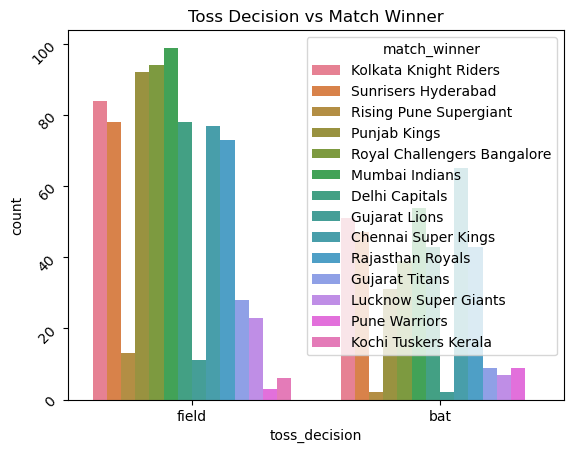

In [8]:
sns.countplot(x="toss_decision", hue="match_winner", data=matches)
plt.title("Toss Decision vs Match Winner")
plt.yticks(rotation=45)
plt.show()

5. Ball-by-Ball Insights (Run Distribution)

plt.figure(figsize=(10,6))
sns.histplot(data['batter_runs'], bins=10, kde=True, color="orange")
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

Preprocessing for Seasonal Trends

Let's aggregate the data by season:

In [9]:
# Total runs per season (from ball-by-ball data)
season_runs = data.groupby("season_id")['total_runs'].sum()

# Total wickets per season
# Ensure is_wicket is boolean
data['is_wicket'] = data['is_wicket'].astype(int)

# Aggregate wickets per season
season_wickets = data.groupby("season_id")['is_wicket'].sum()

# Wins per season (number of matches with a winner)
# Clean season column
matches['season'] = matches['season'].astype(str)
matches['season_clean'] = matches['season'].str.extract(r'(\d{4})').astype(int)
# Number of matches with a winner per season
season_wins = matches.groupby("season_clean")['match_winner'].nunique()

# Alternative: total matches played per season
season_matches = matches.groupby("season_clean")['match_id'].count()

# Alternative: average win margin per season
avg_win_margin = matches.groupby("season_clean")[['win_by_runs','win_by_wickets']].mean()

6. Correlation & Heatmap (Numerical Features)

Check for missing values

In [10]:
print(matches.isnull().sum())
print(players.isnull().sum())
print(teams.isnull().sum())
print(data.isnull().sum())

match_id              0
season_id             0
balls_per_over        0
city                 51
match_date            0
event_name            0
match_number         70
gender                0
match_type            0
format                0
overs                 0
season                0
team_type             0
venue                 0
toss_winner           1
team1                 0
team2                 0
toss_decision         1
match_winner          8
win_by_runs           0
win_by_wickets        0
player_of_match       8
result                0
stage              1165
season_clean          0
dtype: int64
player_id           0
player_name         0
bat_style           0
bowl_style          0
field_pos           0
player_full_name    0
player_name2        0
player_image        0
dtype: int64
team_id            0
team_name          0
team_name_short    0
image_url          0
dtype: int64
season_id            0
match_id             0
batter               0
bowler               0
non_strik

In [11]:
# Drop rows with missing values in key columns
matches = matches.dropna(subset=['win_by_runs','win_by_wickets','season_clean'])

# OR fill missing values with 0 (if appropriate)
matches['win_by_runs'] = matches['win_by_runs'].fillna(0)
matches['win_by_wickets'] = matches['win_by_wickets'].fillna(0)

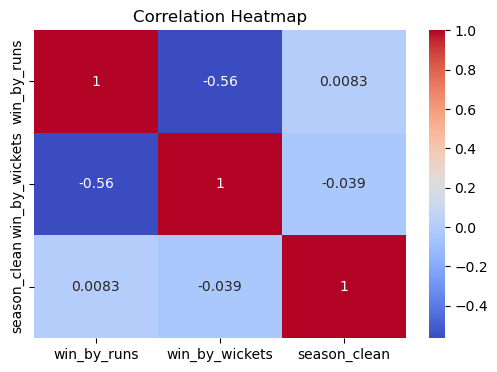

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = matches[['win_by_runs','win_by_wickets','season_clean']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

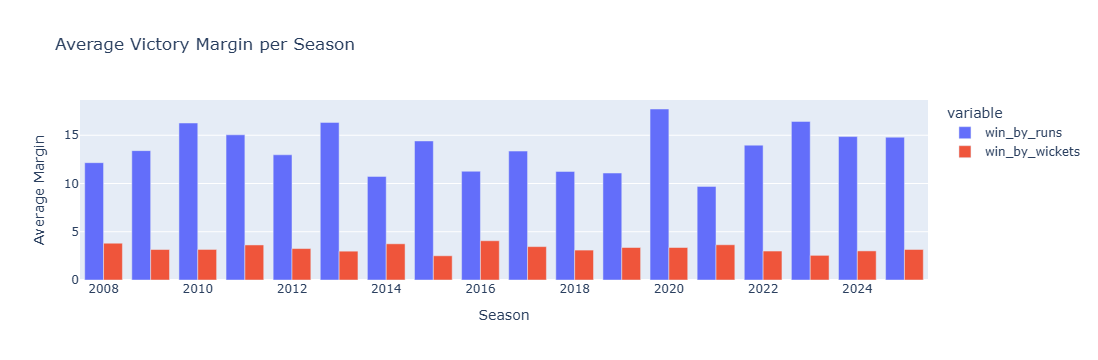

In [13]:
import plotly.express as px

season_trends = matches.groupby('season_clean')[['win_by_runs','win_by_wickets']].mean().reset_index()

fig = px.bar(
    season_trends,
    x='season_clean',
    y=['win_by_runs','win_by_wickets'],
    barmode='group',
    title="Average Victory Margin per Season",
    labels={'season_clean':'Season','value':'Average Margin'}
)
fig.show()

Seasonal Trend Dashboard

In [14]:
# Ensure is_wicket is numeric (1 for wicket, 0 otherwise)
data['is_wicket'] = data['is_wicket'].astype(int)

# Total wickets per season
season_wickets = data.groupby("season_id")['is_wicket'].sum()

In [15]:
# Matches per season
season_matches = matches.groupby("season_clean")['match_id'].count()

# Unique winners per season
season_unique_winners = matches.groupby("season_clean")['match_winner'].nunique()

# Average win margin per season
avg_win_margin = matches.groupby("season_clean")[['win_by_runs','win_by_wickets']].mean()

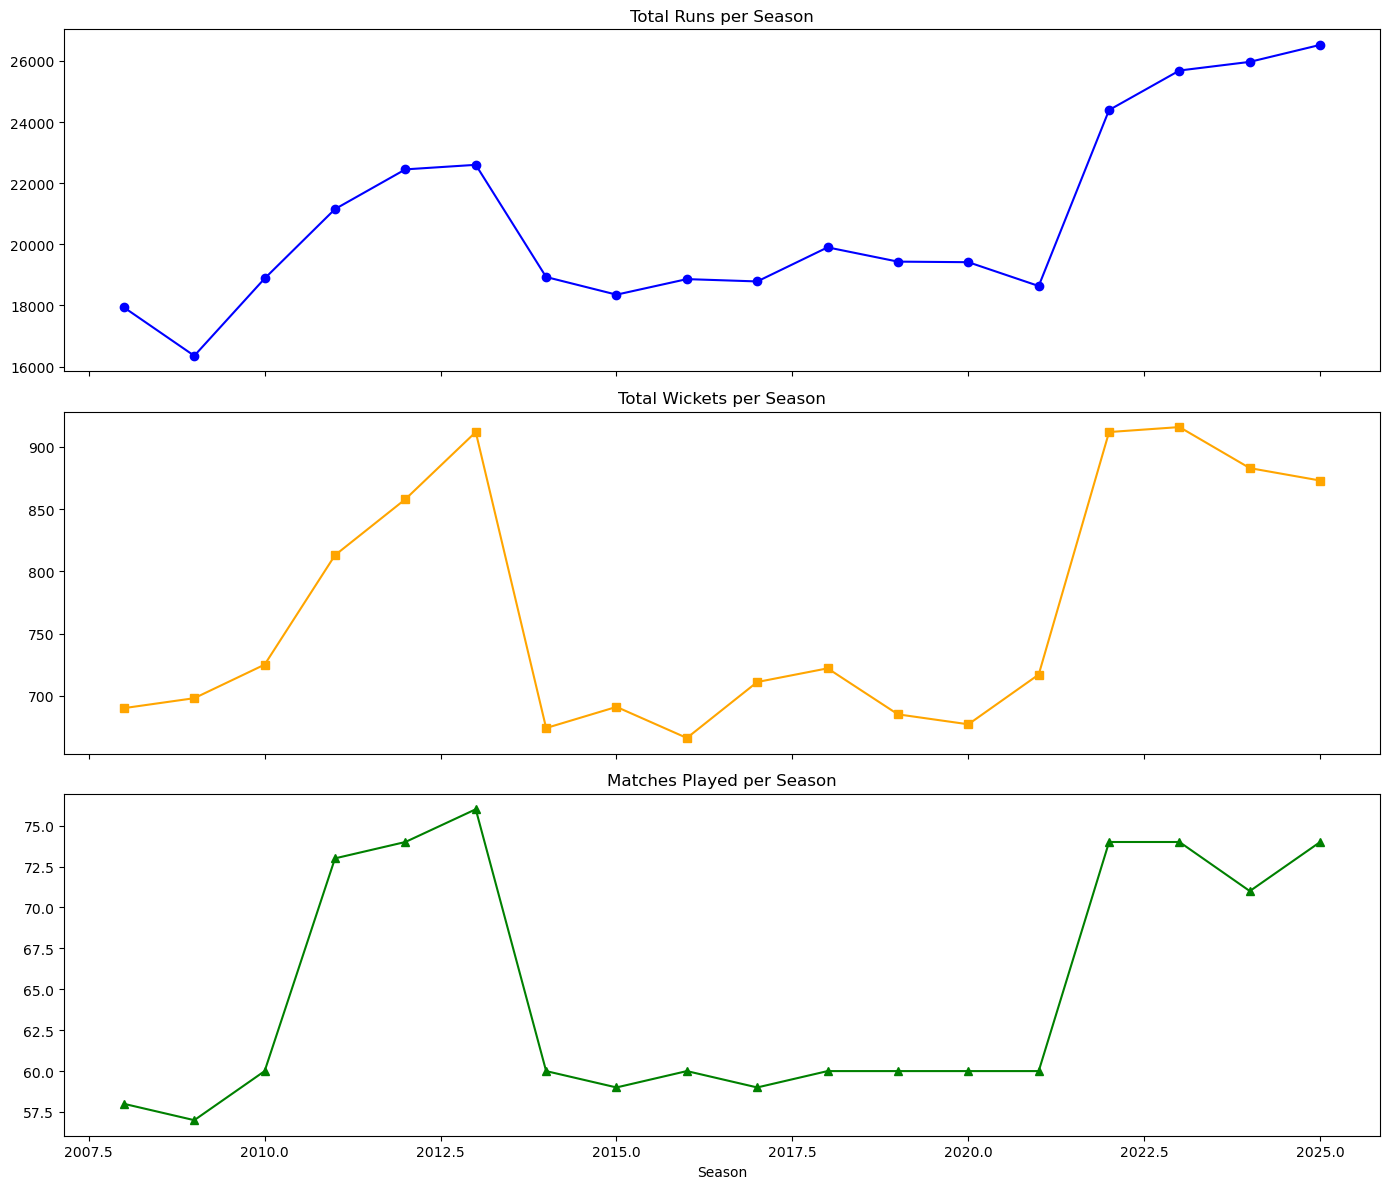

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14,12), sharex=True)

# Runs
axes[0].plot(season_runs.index, season_runs.values, marker='o', color='blue')
axes[0].set_title("Total Runs per Season")

# Wickets
axes[1].plot(season_wickets.index, season_wickets.values, marker='s', color='orange')
axes[1].set_title("Total Wickets per Season")

# Matches
axes[2].plot(season_matches.index, season_matches.values, marker='^', color='green')
axes[2].set_title("Matches Played per Season")

plt.xlabel("Season")
plt.tight_layout()
plt.show()

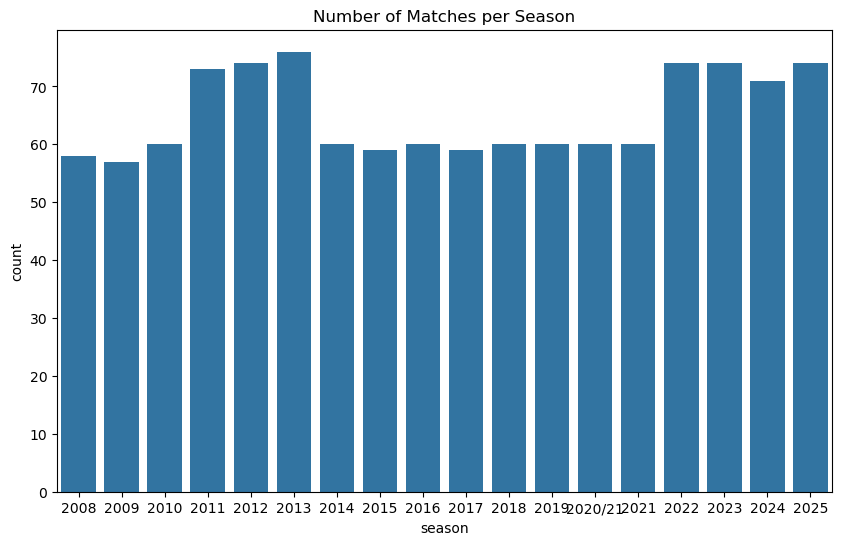

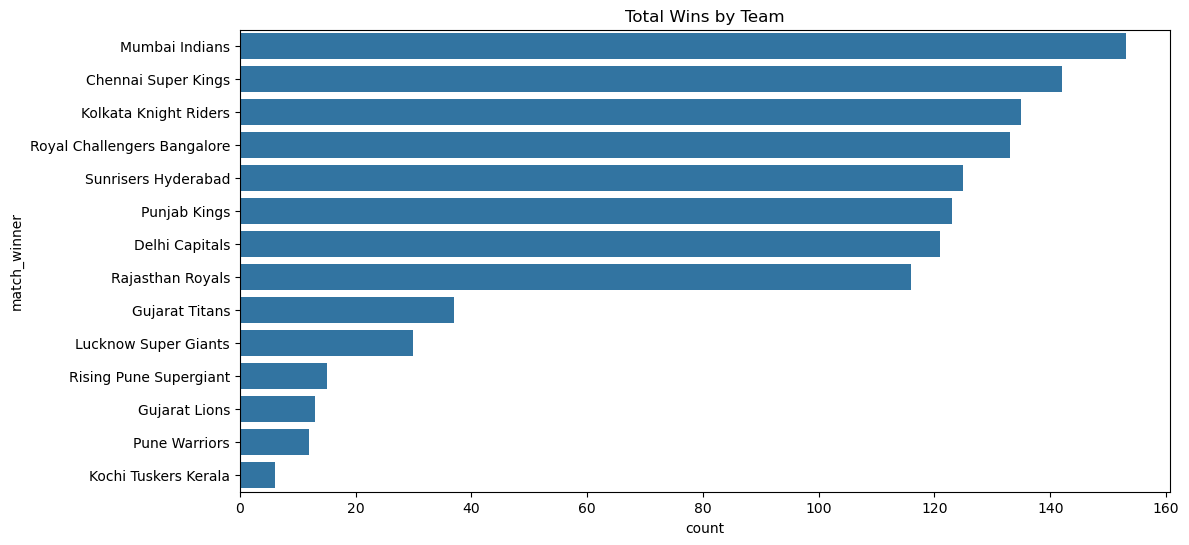

In [17]:
# ------------------ Exploratory Graphs ------------------
plt.figure(figsize=(10,6))
sns.countplot(x="season", data=matches, order=sorted(matches['season'].unique()))
plt.title("Number of Matches per Season")
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(y="match_winner", data=matches, order=matches['match_winner'].value_counts().index)
plt.title("Total Wins by Team")
plt.show()

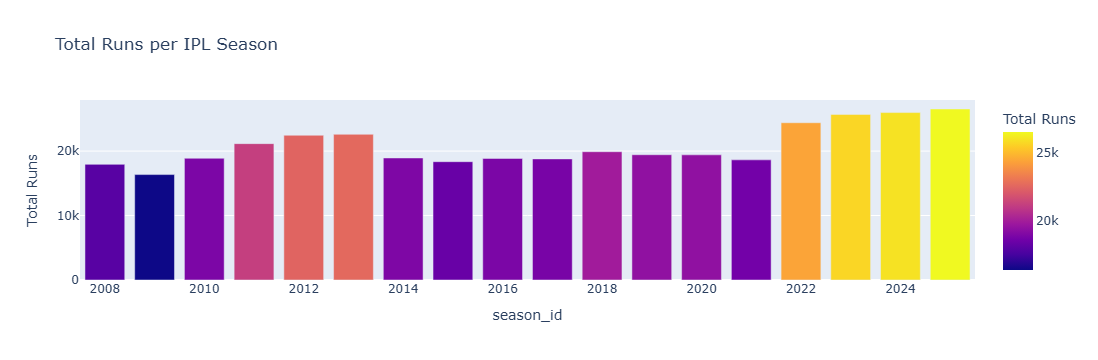

In [18]:
import pandas as pd
import plotly.express as px

# Use ball-by-ball data for runs
# Aggregate runs from ball-by-ball dataset
season_runs = data.groupby("season_id")['batter_runs'].sum().reset_index()
data['runs_scored'] = data['batter_runs'] + data['extras']
season_runs = data.groupby("season_id")['runs_scored'].sum().reset_index()

# Make sure is_wicket is numeric
data['is_wicket'] = data['is_wicket'].astype(int)

season_wickets = data.groupby("season_id")['is_wicket'].sum().reset_index()
season_matches = matches.groupby("season_id")['match_id'].count().reset_index()

# Create bar chart
fig = px.bar(
    season_runs,
    x="season_id",
    y="runs_scored",
    title="Total Runs per IPL Season",
    labels={"season": "Season", "runs_scored": "Total Runs"},
    color="runs_scored"
)

fig.show()

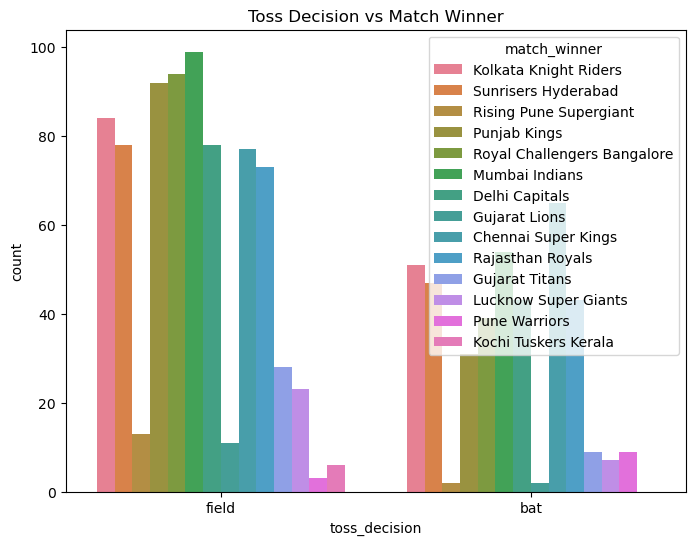

In [19]:
# Toss decision vs match outcome
plt.figure(figsize=(8,6))
sns.countplot(x="toss_decision", hue="match_winner", data=matches)
plt.title("Toss Decision vs Match Winner")
plt.show()

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\Users\bhara\coding\Lib\site-packages\sta

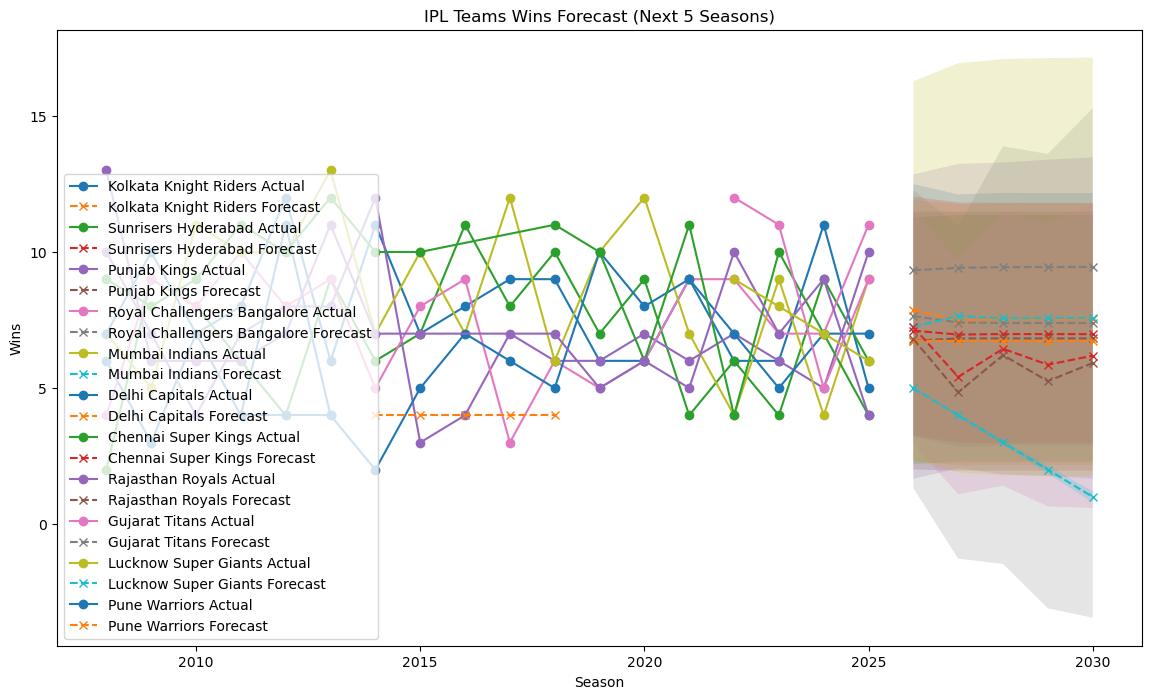


Forecasted wins for Kolkata Knight Riders:
Season 2026.0: 7.86 wins (95% CI: 3.24 – 12.49)
Season 2027.0: 7.48 wins (95% CI: 2.85 – 12.12)
Season 2028.0: 7.53 wins (95% CI: 2.89 – 12.17)
Season 2029.0: 7.53 wins (95% CI: 2.89 – 12.16)
Season 2030.0: 7.53 wins (95% CI: 2.89 – 12.16)

Forecasted wins for Sunrisers Hyderabad:
Season 2026.0: 7.11 wins (95% CI: 2.31 – 11.90)
Season 2027.0: 6.97 wins (95% CI: 2.16 – 11.77)
Season 2028.0: 6.98 wins (95% CI: 2.18 – 11.79)
Season 2029.0: 6.98 wins (95% CI: 2.18 – 11.79)
Season 2030.0: 6.98 wins (95% CI: 2.18 – 11.79)

Forecasted wins for Punjab Kings:
Season 2026.0: 6.74 wins (95% CI: 2.20 – 11.27)
Season 2027.0: 6.83 wins (95% CI: 2.30 – 11.36)
Season 2028.0: 6.82 wins (95% CI: 2.29 – 11.35)
Season 2029.0: 6.82 wins (95% CI: 2.29 – 11.35)
Season 2030.0: 6.82 wins (95% CI: 2.29 – 11.35)

Forecasted wins for Royal Challengers Bangalore:
Season 2026.0: 7.65 wins (95% CI: 3.26 – 12.03)
Season 2027.0: 7.41 wins (95% CI: 3.00 – 11.82)
Season 2028.0

In [20]:
# ------------------ TEAM FORECASTS ------------------
forecast_horizon = 5
teams_list = matches['match_winner'].dropna().unique()

plt.figure(figsize=(14,8))
team_forecasts = {}

for team in teams_list:
    team_wins = matches[matches['match_winner'] == team].groupby("season_id").size()
    if len(team_wins) < 3:
        continue
    try:
        model = ARIMA(team_wins, order=(1,1,1))
        fit = model.fit()
        forecast = fit.get_forecast(steps=forecast_horizon)
        pred = forecast.predicted_mean
        conf_int = forecast.conf_int()
        future_index = list(range(team_wins.index[-1]+1, team_wins.index[-1]+1+forecast_horizon))
        
        team_forecasts[team] = pd.DataFrame({
            "Season": future_index,
            "Forecasted Wins": pred.values,
            "Lower CI": conf_int.iloc[:,0].values,
            "Upper CI": conf_int.iloc[:,1].values
        })
        
        plt.plot(team_wins.index, team_wins.values, marker='o', label=f"{team} Actual")
        plt.plot(future_index, pred, marker='x', linestyle="--", label=f"{team} Forecast")
        plt.fill_between(future_index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
    except Exception as e:
        print(f"Skipping {team} due to error: {e}")

plt.title("IPL Teams Wins Forecast (Next 5 Seasons)")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.legend()
plt.show()

# Print exact forecasts
for team, df in team_forecasts.items():
    print(f"\nForecasted wins for {team}:")
    for _, row in df.iterrows():
        print(f"Season {row['Season']}: {row['Forecasted Wins']:.2f} wins "
              f"(95% CI: {row['Lower CI']:.2f} – {row['Upper CI']:.2f})")


Forecasted Player of the Match awards for 245.0:
Season 2022: 2.60 awards (95% CI: 0.72 – 4.48)
Season 2023: 2.45 awards (95% CI: 0.56 – 4.35)
Season 2024: 2.49 awards (95% CI: 0.49 – 4.49)


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



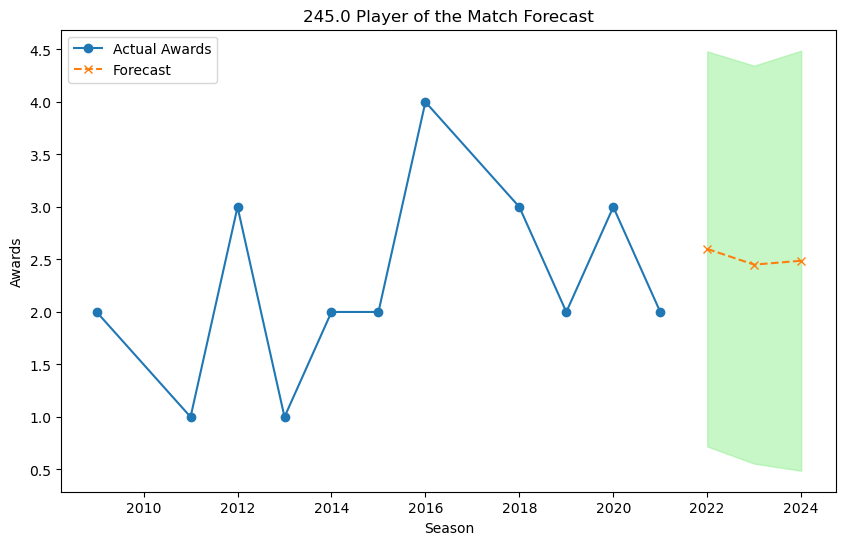


Forecasted Player of the Match awards for 1.0:
Season 2021: 1.56 awards (95% CI: -2.06 – 5.18)
Season 2022: 1.85 awards (95% CI: -2.37 – 6.06)
Season 2023: 2.00 awards (95% CI: -2.43 – 6.43)


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No su

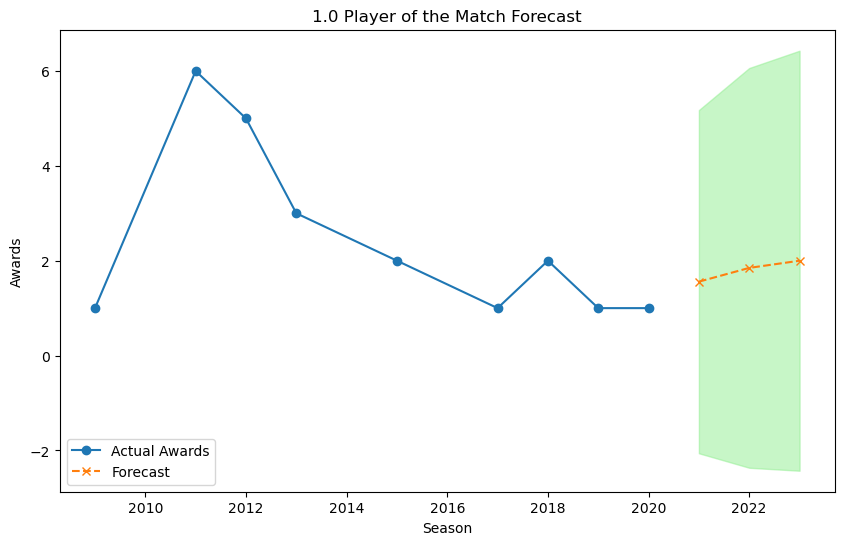


Forecasted Player of the Match awards for 25.0:
Season 2026: 1.49 awards (95% CI: -0.17 – 3.16)
Season 2027: 1.63 awards (95% CI: -0.06 – 3.33)
Season 2028: 1.59 awards (95% CI: -0.11 – 3.30)


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



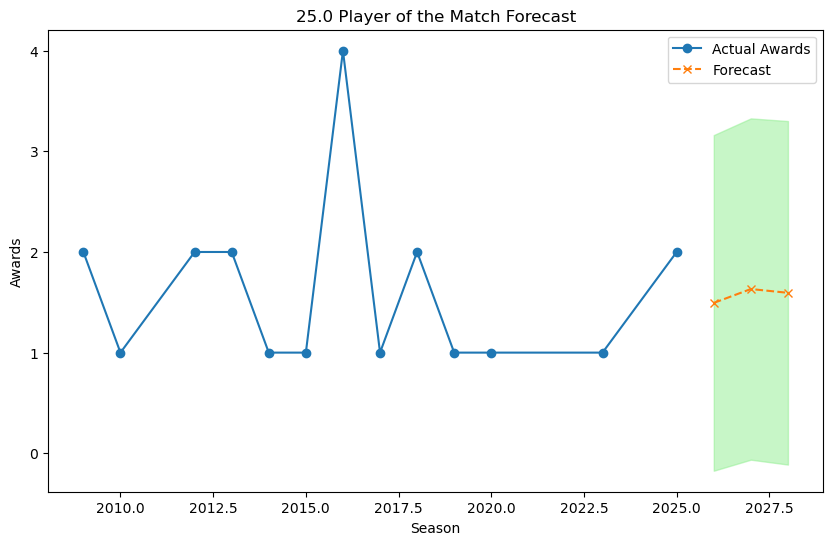


Forecasted Player of the Match awards for 332.0:
Season 2026: 1.91 awards (95% CI: -0.64 – 4.47)
Season 2027: 1.61 awards (95% CI: -0.95 – 4.17)
Season 2028: 1.71 awards (95% CI: -0.95 – 4.37)


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



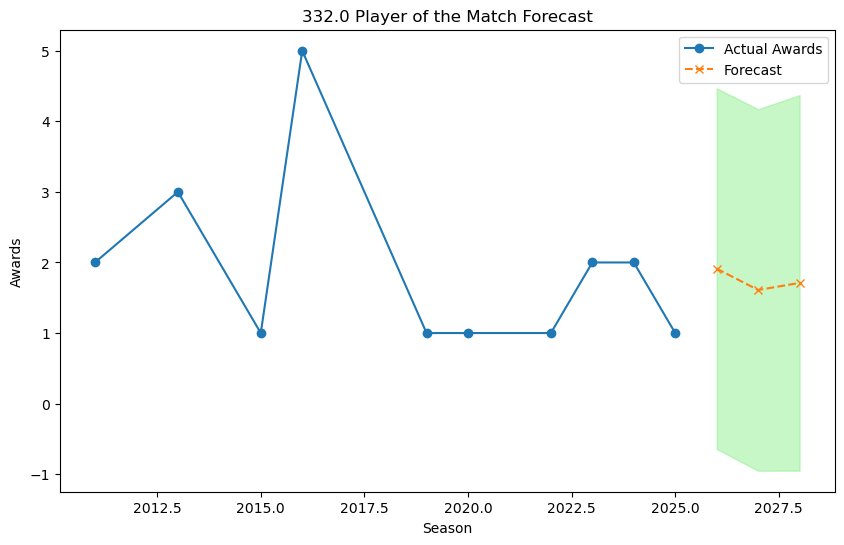


Forecasted Player of the Match awards for 38.0:
Season 2026: 1.67 awards (95% CI: 0.17 – 3.16)
Season 2027: 1.44 awards (95% CI: -0.09 – 2.98)
Season 2028: 1.52 awards (95% CI: -0.04 – 3.07)


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



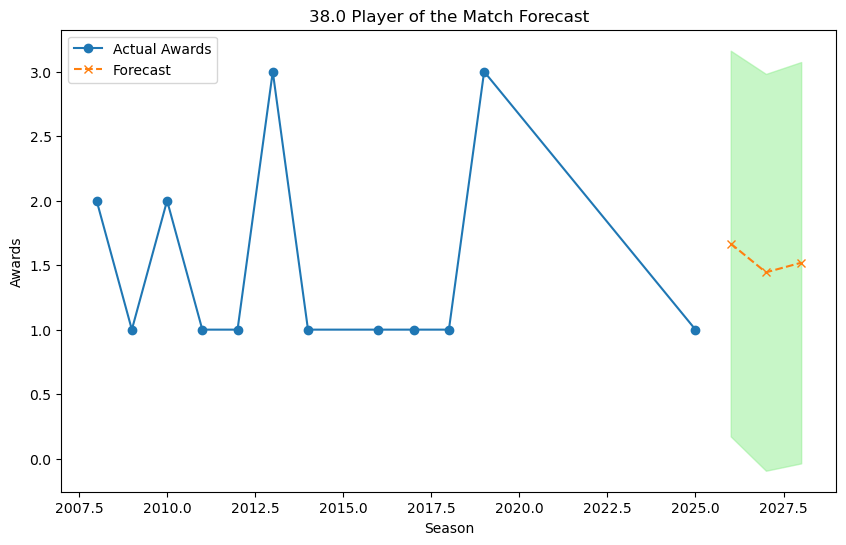

In [21]:
# ------------------ PLAYER FORECASTS ------------------
top_players = matches['player_of_match'].value_counts().head(5).index

for player in top_players:
    player_awards = matches[matches['player_of_match'] == player].groupby("season_id").size()
    if len(player_awards) < 3:
        continue
    model = ARIMA(player_awards, order=(1,1,1))
    fit = model.fit()
    forecast = fit.get_forecast(steps=3)
    pred = forecast.predicted_mean
    conf_int = forecast.conf_int()
    future_index = list(range(player_awards.index[-1]+1, player_awards.index[-1]+1+len(pred)))
    
    print(f"\nForecasted Player of the Match awards for {player}:")
    for season, value, (low, high) in zip(future_index, pred, conf_int.values):
        print(f"Season {season}: {value:.2f} awards (95% CI: {low:.2f} – {high:.2f})")
    
    plt.figure(figsize=(10,6))
    plt.plot(player_awards.index, player_awards.values, marker='o', label="Actual Awards")
    plt.plot(future_index, pred, marker='x', linestyle="--", label="Forecast")
    plt.fill_between(future_index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='lightgreen', alpha=0.5)
    plt.title(f"{player} Player of the Match Forecast")
    plt.xlabel("Season")
    plt.ylabel("Awards")
    plt.legend()
    plt.show()

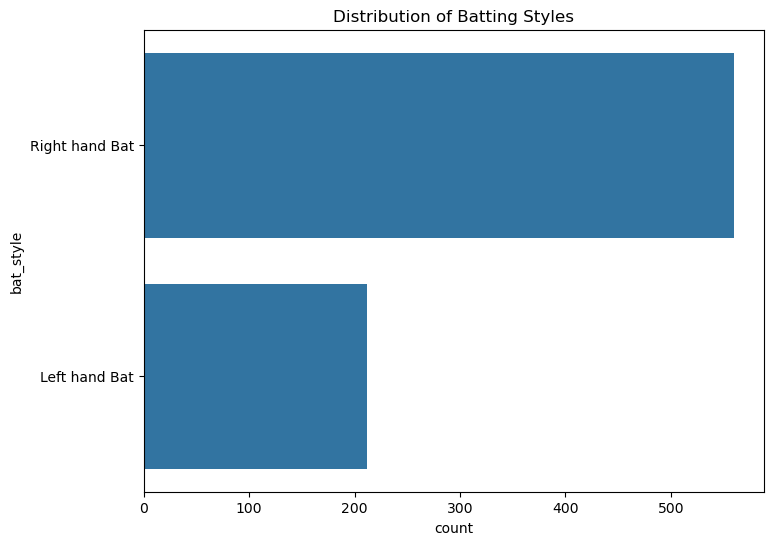

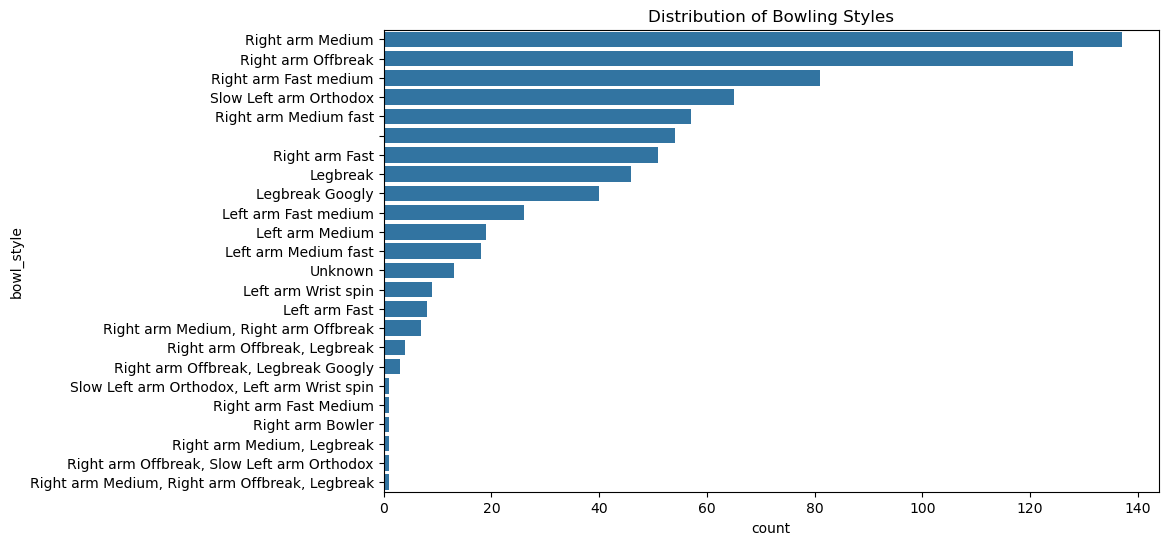


Sample Player Role Clusters:
      player_name       bat_style              bowl_style  cluster
0     Mohsin Khan   Left hand Bat    Left arm Medium fast        1
1     Rashid Khan  Right hand Bat         Legbreak Googly        0
2        K Rabada   Left hand Bat          Right arm Fast        0
3         SN Khan  Right hand Bat                Legbreak        1
4      MN Samuels  Right hand Bat      Right arm Offbreak        2
5       SB Jakati   Left hand Bat  Slow Left arm Orthodox        2
6       DA Warner   Left hand Bat                Legbreak        1
7      MP Stoinis  Right hand Bat        Right arm Medium        0
8       R Tewatia   Left hand Bat                Legbreak        1
9     RA Tripathi  Right hand Bat        Right arm Medium        0
10      RD Chahar  Right hand Bat         Legbreak Googly        0
11       S Nadeem  Right hand Bat  Slow Left arm Orthodox        2
12      MK Pandey  Right hand Bat        Right arm Medium        0
13  KS Williamson  Right hand Ba

C:\Users\bhara\coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.



In [22]:
# ------------------ PLAYER PERFORMANCE ANALYTICS ------------------
from sklearn.cluster import KMeans
# Batting style distribution
plt.figure(figsize=(8,6))
sns.countplot(y="bat_style", data=players, order=players['bat_style'].value_counts().index)
plt.title("Distribution of Batting Styles")
plt.show()

# Bowling style distribution
plt.figure(figsize=(10,6))
sns.countplot(y="bowl_style", data=players, order=players['bowl_style'].value_counts().index)
plt.title("Distribution of Bowling Styles")
plt.show()

# Player clustering (batsmen, bowlers, all-rounders)
players['bat_encoded'] = players['bat_style'].astype('category').cat.codes
players['bowl_encoded'] = players['bowl_style'].astype('category').cat.codes
X = players[['bat_encoded','bowl_encoded']].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42)
players['cluster'] = kmeans.fit_predict(X)

print("\nSample Player Role Clusters:")
print(players[['player_name','bat_style','bowl_style','cluster']].head(20))

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [24]:
# ------------------ MACHINE LEARNING REGRESSION ------------------
player_awards_count = matches['player_of_match'].value_counts().reset_index()
player_awards_count.columns = ['player_name','awards']

# Fix merge error by casting to string
player_awards_count['player_name'] = player_awards_count['player_name'].astype(str)
players['player_name'] = players['player_name'].astype(str)

player_data = pd.merge(player_awards_count, 
                       players[['player_name','bat_style','bowl_style']], 
                       on='player_name', how='left')

player_data['bat_encoded'] = player_data['bat_style'].astype('category').cat.codes
player_data['bowl_encoded'] = player_data['bowl_style'].astype('category').cat.codes

X = player_data[['bat_encoded','bowl_encoded']]
y = player_data['awards']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\nMachine Learning Regression Results:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Feature Importance (Batting vs Bowling styles):", rf.feature_importances_)


Machine Learning Regression Results:
Mean Squared Error: 19.414661755728684
Feature Importance (Batting vs Bowling styles): [0. 0.]


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\Users\bhara\coding\Lib\site-packages\sta

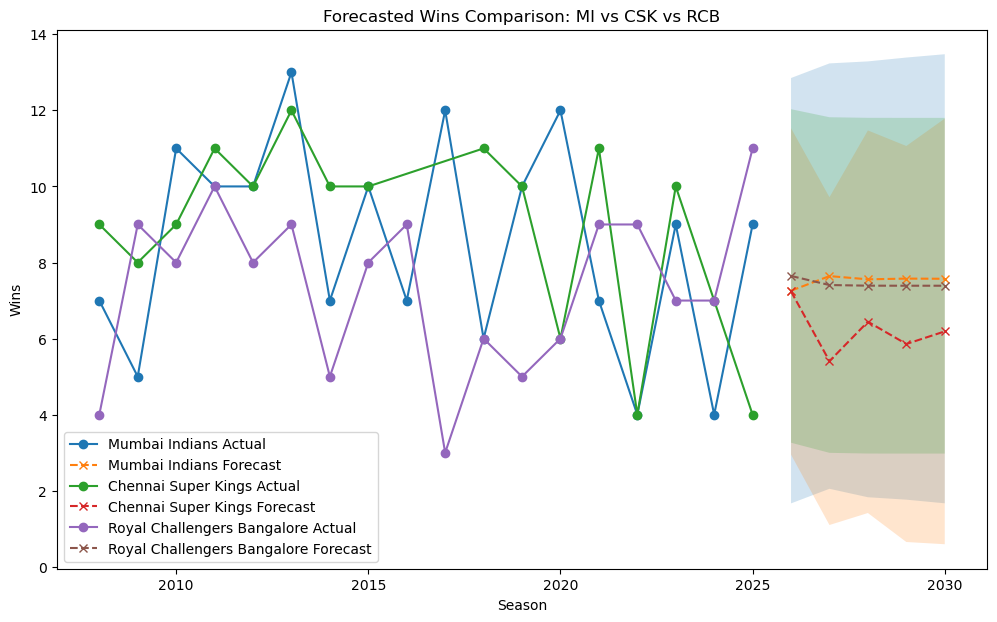

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load matches
matches = pd.read_csv("ipl_matches_data.csv", encoding="latin1")

# Clean season column
matches['season'] = matches['season'].astype(str)
matches['season_clean'] = matches['season'].str.extract(r'(\d{4})').astype(int)

# Teams to compare
top_teams = ["Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bangalore"]
forecast_horizon = 5

plt.figure(figsize=(12,7))

for team in top_teams:
    team_wins = matches[matches['match_winner'] == team].groupby("season_clean").size()
    if len(team_wins) < 3:
        continue
    
    model = ARIMA(team_wins, order=(1,1,1))
    fit = model.fit()
    forecast = fit.get_forecast(steps=forecast_horizon)
    pred = forecast.predicted_mean
    conf_int = forecast.conf_int()
    
    future_index = list(range(team_wins.index[-1]+1, team_wins.index[-1]+1+forecast_horizon))
    
    # Plot actual + forecast
    plt.plot(team_wins.index, team_wins.values, marker='o', label=f"{team} Actual")
    plt.plot(future_index, pred, marker='x', linestyle="--", label=f"{team} Forecast")
    plt.fill_between(future_index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)

plt.title("Forecasted Wins Comparison: MI vs CSK vs RCB")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.legend()
plt.show()


Average Runs per Match

In [26]:
# First, compute total runs per season from ball-by-ball
data['runs_scored'] = data['batter_runs'] + data['extras']
season_runs = data.groupby("season_id")['runs_scored'].sum().reset_index()

# Matches per season from matches dataset
season_matches = matches.groupby("season_id")['match_id'].count().reset_index()

# Merge runs and matches
season_summary = season_runs.merge(season_matches, on="season_id")

# Calculate average runs per match
season_summary['avg_runs_per_match'] = season_summary['runs_scored'] / season_summary['match_id']


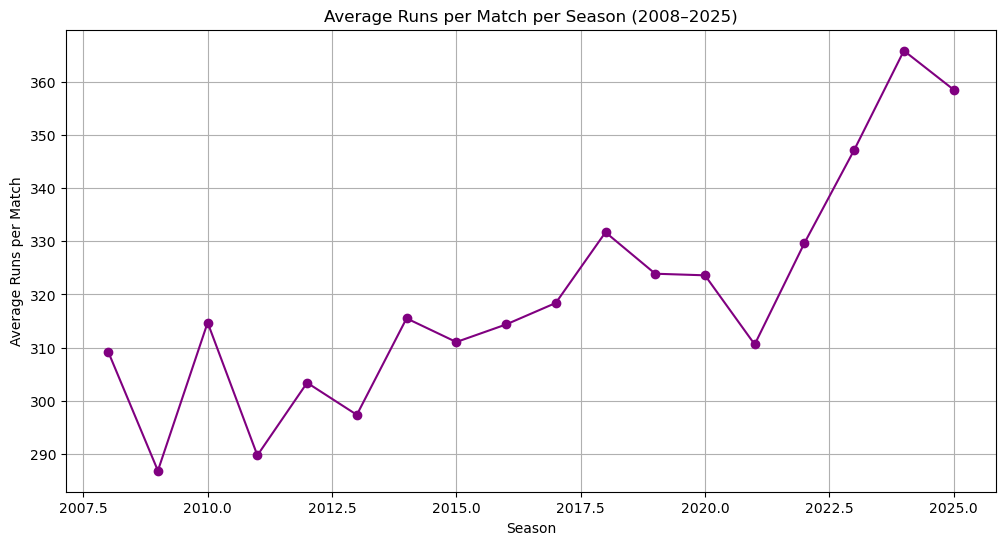

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(season_summary['season_id'], season_summary['avg_runs_per_match'], marker='o', color='purple')
plt.title("Average Runs per Match per Season (2008–2025)")
plt.xlabel("Season")
plt.ylabel("Average Runs per Match")
plt.grid(True)
plt.show()


In [28]:
# Count actual dismissals per season
season_wickets = data[data['player_out'].notna()].groupby("season_id")['player_out'].count().reset_index()
season_wickets.rename(columns={'player_out':'wickets'}, inplace=True)

In [29]:
season_matches = matches.groupby("season_id")['match_id'].count().reset_index()

In [30]:
# Merge runs, wickets, matches
season_summary = season_runs.merge(season_matches, on="season_id").merge(season_wickets, on="season_id")

# Calculate averages
season_summary['avg_runs_per_match'] = season_summary['runs_scored'] / season_summary['match_id']
season_summary['avg_wickets_per_match'] = season_summary['wickets'] / season_summary['match_id']

Average Wickets per Match

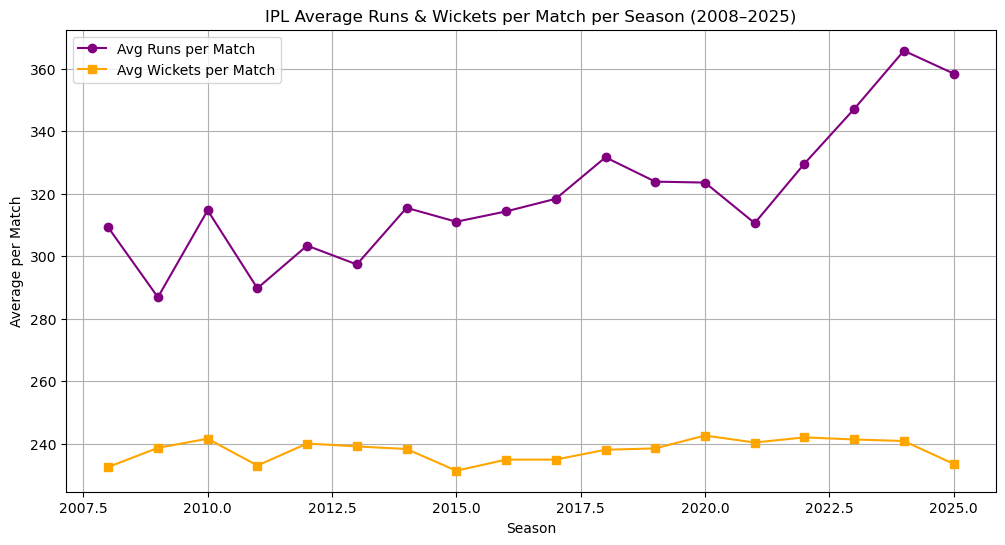

In [31]:
plt.figure(figsize=(12,6))
plt.plot(season_summary['season_id'], season_summary['avg_runs_per_match'], marker='o', color='purple', label="Avg Runs per Match")
plt.plot(season_summary['season_id'], season_summary['avg_wickets_per_match'], marker='s', color='orange', label="Avg Wickets per Match")

plt.title("IPL Average Runs & Wickets per Match per Season (2008–2025)")
plt.xlabel("Season")
plt.ylabel("Average per Match")
plt.legend()
plt.grid(True)
plt.show()

stacked bar chart - runs vs wickets side by side per season

In [32]:
import numpy as np

# Ensure wickets are counted correctly
season_wickets = data[data['player_out'].notna()].groupby("season_id")['player_out'].count().reset_index()
season_wickets.rename(columns={'player_out':'wickets'}, inplace=True)

# Runs per season
data['runs_scored'] = data['batter_runs'] + data['extras']
season_runs = data.groupby("season_id")['runs_scored'].sum().reset_index()

# Matches per season
season_matches = matches.groupby("season_id")['match_id'].count().reset_index()

# Merge all
season_summary = season_runs.merge(season_matches, on="season_id").merge(season_wickets, on="season_id")

# Calculate averages
season_summary['avg_runs_per_match'] = season_summary['runs_scored'] / season_summary['match_id']
season_summary['avg_wickets_per_match'] = season_summary['wickets'] / season_summary['match_id']

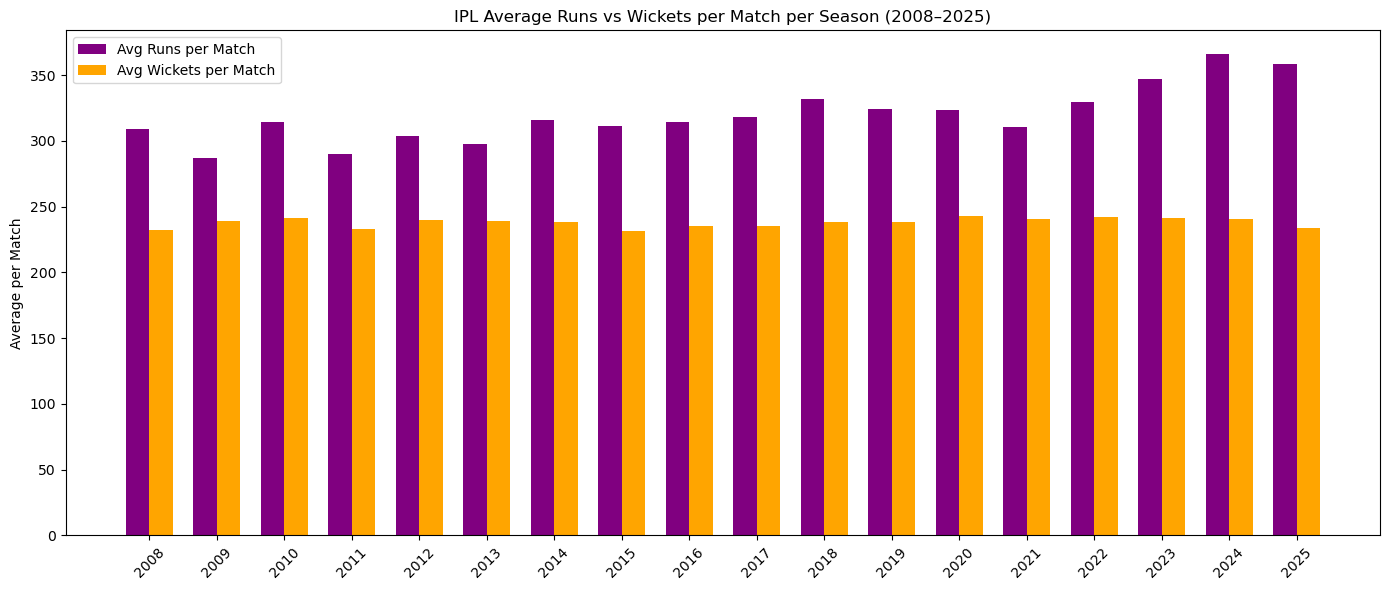

In [33]:
# Bar chart comparing runs vs wickets per season
x = np.arange(len(season_summary['season_id']))
width = 0.35

fig, ax = plt.subplots(figsize=(14,6))
ax.bar(x - width/2, season_summary['avg_runs_per_match'], width, label='Avg Runs per Match', color='purple')
ax.bar(x + width/2, season_summary['avg_wickets_per_match'], width, label='Avg Wickets per Match', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(season_summary['season_id'], rotation=45)
ax.set_ylabel("Average per Match")
ax.set_title("IPL Average Runs vs Wickets per Match per Season (2008–2025)")
ax.legend()
plt.tight_layout()
plt.show()

Team-wise Staked bar chart

In [34]:
# Runs scored per team per season
data['runs_scored'] = data['batter_runs'] + data['extras']
team_runs = data.groupby(['season_id','team_batting'])['runs_scored'].sum().reset_index()

# Wickets taken per team per season
team_wickets = data[data['player_out'].notna()].groupby(['season_id','team_bowling'])['player_out'].count().reset_index()
team_wickets.rename(columns={'player_out':'wickets'}, inplace=True)

# Matches played per team per season
team_matches = pd.concat([
    matches.groupby(['season_id','team1'])['match_id'].count().reset_index().rename(columns={'team1':'team'}),
    matches.groupby(['season_id','team2'])['match_id'].count().reset_index().rename(columns={'team2':'team'})
])
team_matches = team_matches.groupby(['season_id','team'])['match_id'].sum().reset_index()

# Merge runs, wickets, matches
team_summary = team_runs.merge(team_matches, left_on=['season_id','team_batting'], right_on=['season_id','team'])
team_summary = team_summary.merge(team_wickets, left_on=['season_id','team_batting'], right_on=['season_id','team_bowling'], how='left')

# Fill missing wickets with 0
team_summary['wickets'] = team_summary['wickets'].fillna(0)

# Calculate averages
team_summary['avg_runs_per_match'] = team_summary['runs_scored'] / team_summary['match_id']
team_summary['avg_wickets_per_match'] = team_summary['wickets'] / team_summary['match_id']

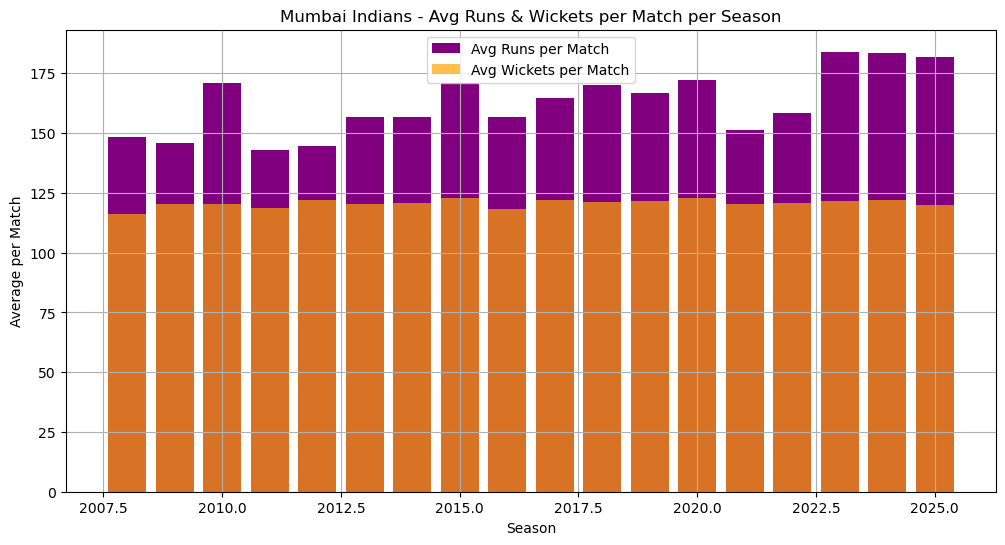

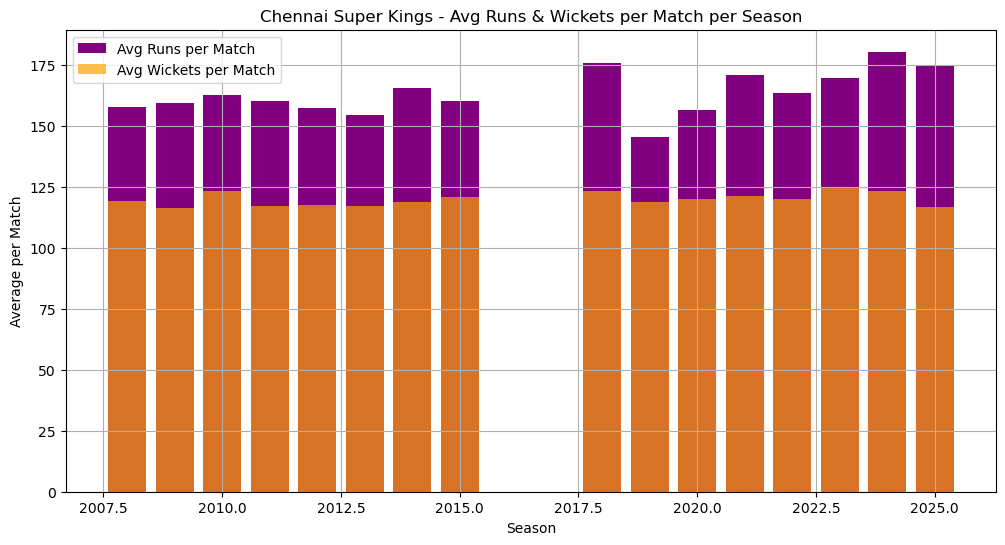

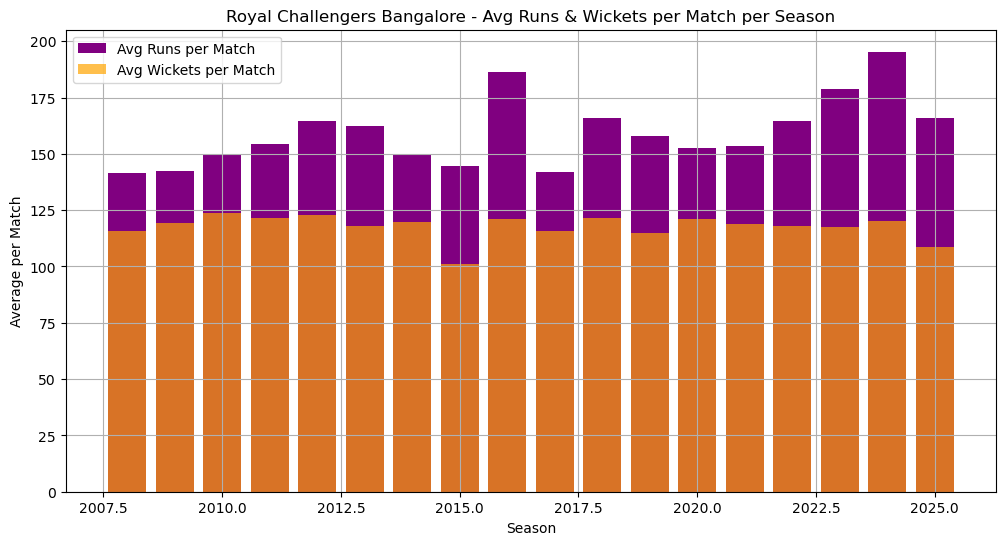

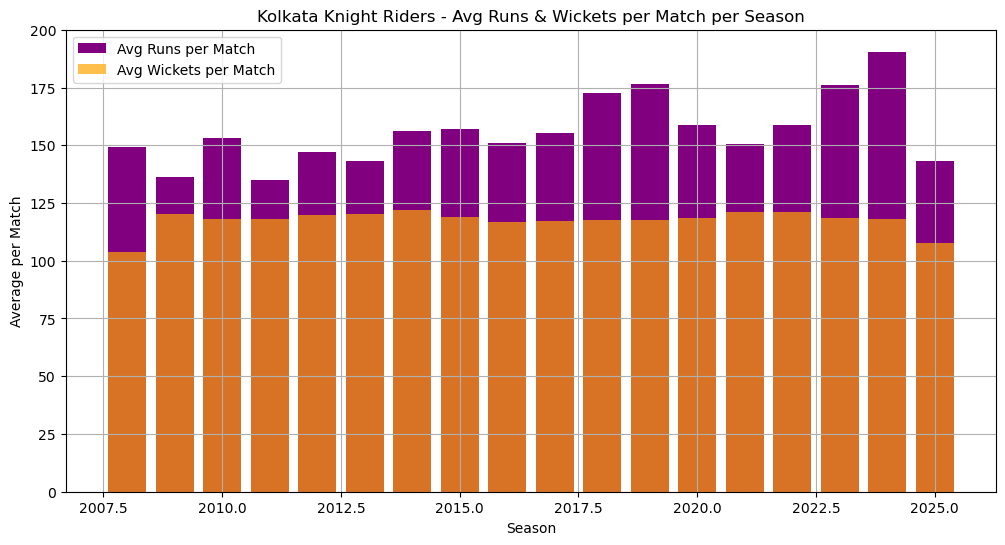

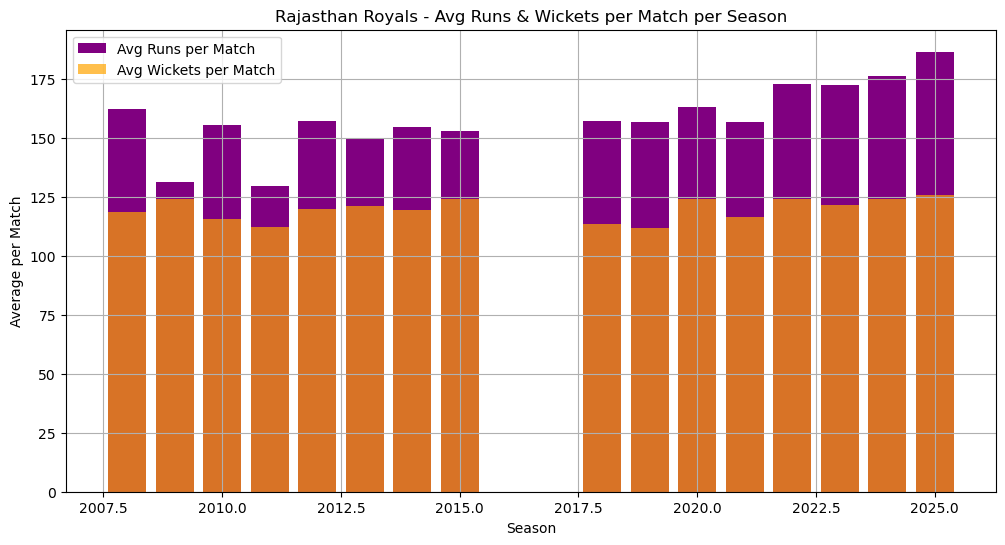

In [35]:
import matplotlib.pyplot as plt

# Example: focus on a few popular teams
teams_to_plot = ['Mumbai Indians','Chennai Super Kings','Royal Challengers Bangalore','Kolkata Knight Riders','Rajasthan Royals']

for team in teams_to_plot:
    subset = team_summary[team_summary['team_batting'] == team]
    plt.figure(figsize=(12,6))
    plt.bar(subset['season_id'], subset['avg_runs_per_match'], label='Avg Runs per Match', color='purple')
    plt.bar(subset['season_id'], subset['avg_wickets_per_match'], label='Avg Wickets per Match', color='orange', alpha=0.7)
    plt.title(f"{team} - Avg Runs & Wickets per Match per Season")
    plt.xlabel("Season")
    plt.ylabel("Average per Match")
    plt.legend()
    plt.grid(True)
    plt.show()

Prepare Data for All Teams

In [36]:
# Runs scored per team per season
data['runs_scored'] = data['batter_runs'] + data['extras']
team_runs = data.groupby(['season_id','team_batting'])['runs_scored'].sum().reset_index()

# Wickets taken per team per season
team_wickets = data[data['player_out'].notna()].groupby(['season_id','team_bowling'])['player_out'].count().reset_index()
team_wickets.rename(columns={'player_out':'wickets'}, inplace=True)

# Matches played per team per season
team_matches = pd.concat([
    matches.groupby(['season_id','team1'])['match_id'].count().reset_index().rename(columns={'team1':'team'}),
    matches.groupby(['season_id','team2'])['match_id'].count().reset_index().rename(columns={'team2':'team'})
])
team_matches = team_matches.groupby(['season_id','team'])['match_id'].sum().reset_index()

# Merge runs, wickets, matches
team_summary = team_runs.merge(team_matches, left_on=['season_id','team_batting'], right_on=['season_id','team'])
team_summary = team_summary.merge(team_wickets, left_on=['season_id','team_batting'], right_on=['season_id','team_bowling'], how='left')

# Fill missing wickets with 0
team_summary['wickets'] = team_summary['wickets'].fillna(0)

# Calculate averages
team_summary['avg_runs_per_match'] = team_summary['runs_scored'] / team_summary['match_id']
team_summary['avg_wickets_per_match'] = team_summary['wickets'] / team_summary['match_id']

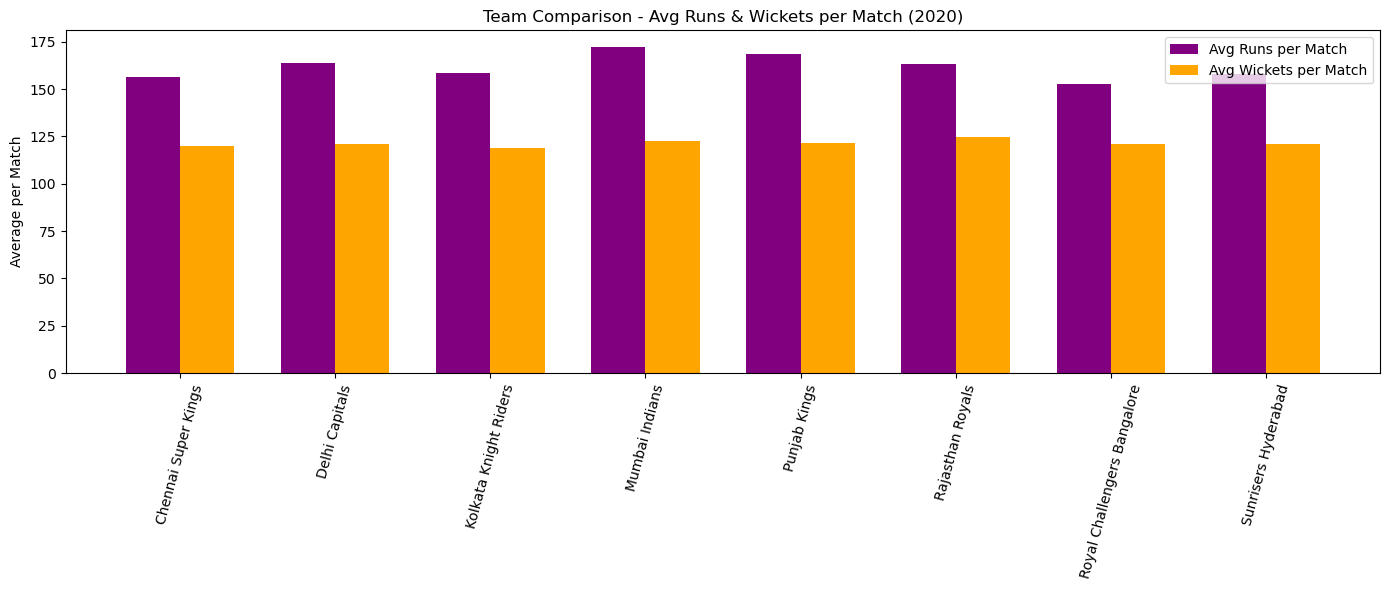

In [37]:
import seaborn as sns

# Choose a season to compare (e.g., 2020)
season_to_plot = 2020
subset = team_summary[team_summary['season_id'] == season_to_plot]

plt.figure(figsize=(14,6))
bar_width = 0.35
x = np.arange(len(subset['team_batting']))

plt.bar(x - bar_width/2, subset['avg_runs_per_match'], bar_width, label='Avg Runs per Match', color='purple')
plt.bar(x + bar_width/2, subset['avg_wickets_per_match'], bar_width, label='Avg Wickets per Match', color='orange')

plt.xticks(x, subset['team_batting'], rotation=75)
plt.ylabel("Average per Match")
plt.title(f"Team Comparison - Avg Runs & Wickets per Match ({season_to_plot})")
plt.legend()
plt.tight_layout()
plt.show()

Animated season‑by‑season dashboard

In [38]:
import plotly.express as px

# Melt the dataframe so runs and wickets can be shown together
team_long = team_summary.melt(
    id_vars=['season_id','team_batting'],
    value_vars=['avg_runs_per_match','avg_wickets_per_match'],
    var_name='metric',
    value_name='average'
)

# Clean metric names
team_long['metric'] = team_long['metric'].replace({
    'avg_runs_per_match':'Avg Runs per Match',
    'avg_wickets_per_match':'Avg Wickets per Match'
})

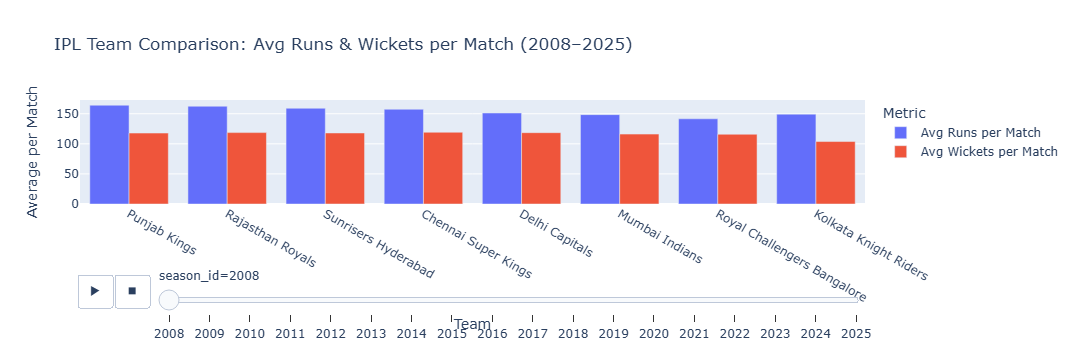

In [39]:
fig = px.bar(
    team_long,
    x="team_batting",
    y="average",
    color="metric",
    barmode="group",
    animation_frame="season_id",
    animation_group="team_batting",
    title="IPL Team Comparison: Avg Runs & Wickets per Match (2008–2025)",
    labels={"team_batting":"Team","average":"Average per Match"}
)

fig.update_layout(xaxis={'categoryorder':'total descending'}, legend_title_text="Metric")
fig.show()

Scatter plot animation

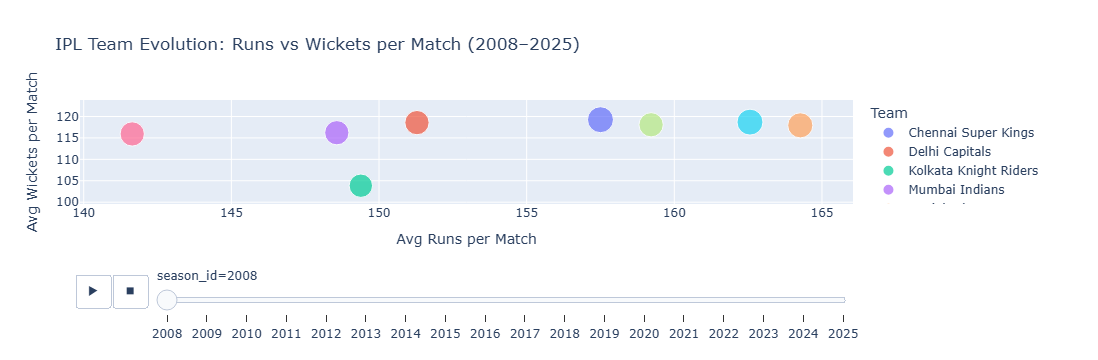

In [40]:
# Scatter plot animation: Runs vs Wickets per team per season
fig = px.scatter(
    team_summary,
    x="avg_runs_per_match",
    y="avg_wickets_per_match",
    size="match_id",                # bubble size = matches played
    color="team_batting",           # color by team
    hover_name="team_batting",
    animation_frame="season_id",    # animate by season
    animation_group="team_batting",
    title="IPL Team Evolution: Runs vs Wickets per Match (2008–2025)",
    labels={
        "avg_runs_per_match":"Avg Runs per Match",
        "avg_wickets_per_match":"Avg Wickets per Match"
    }
)

fig.update_layout(
    xaxis=dict(title="Avg Runs per Match"),
    yaxis=dict(title="Avg Wickets per Match"),
    legend_title_text="Team"
)

fig.show()


Prepare Team‑Wise Trend Data

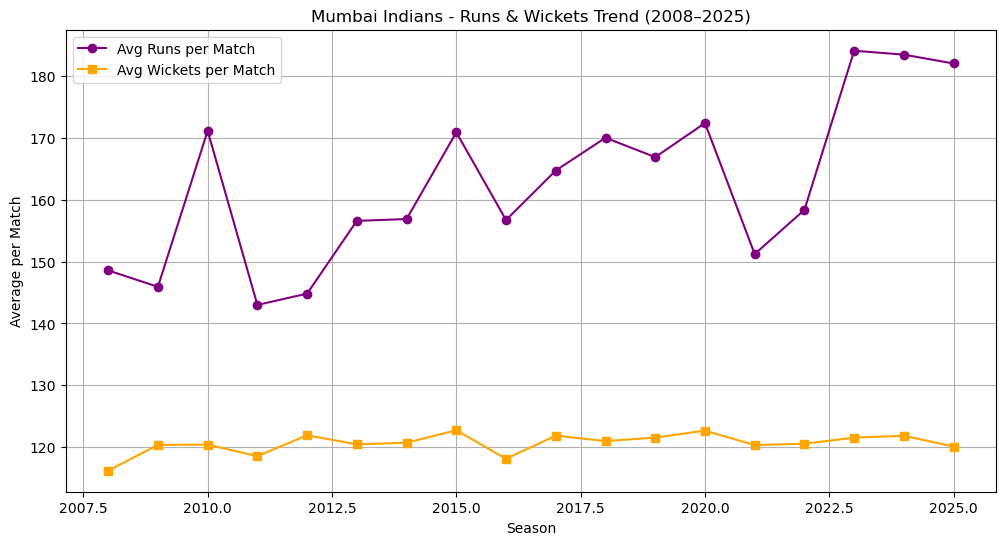

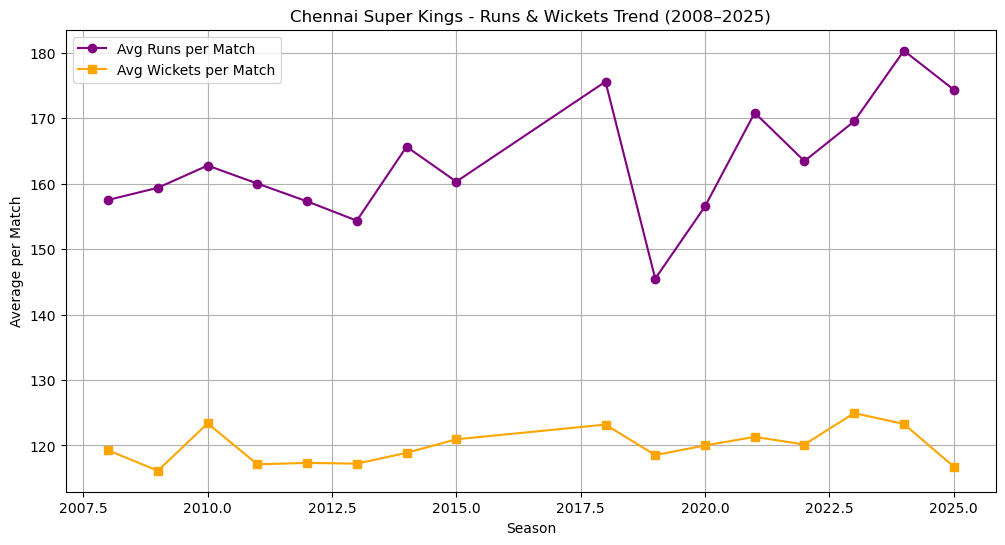

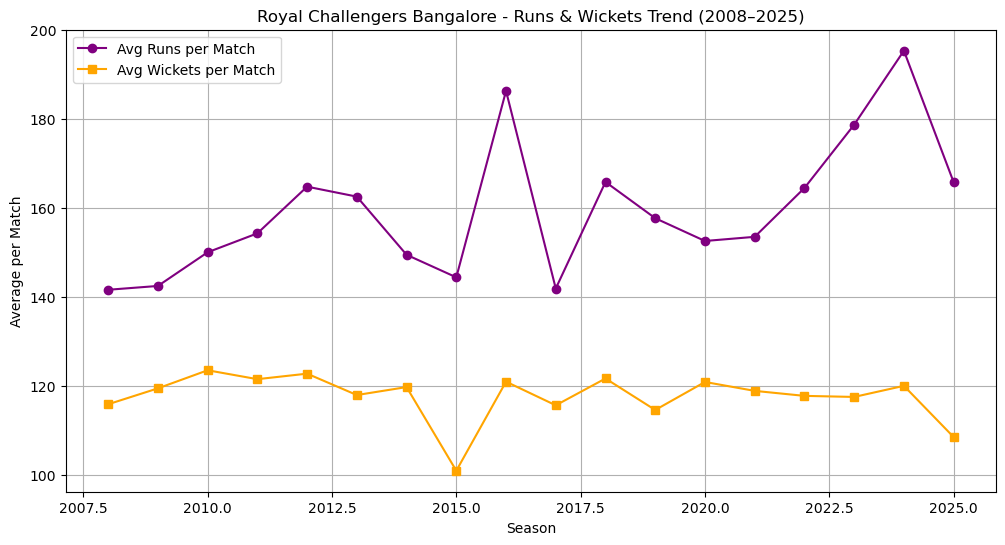

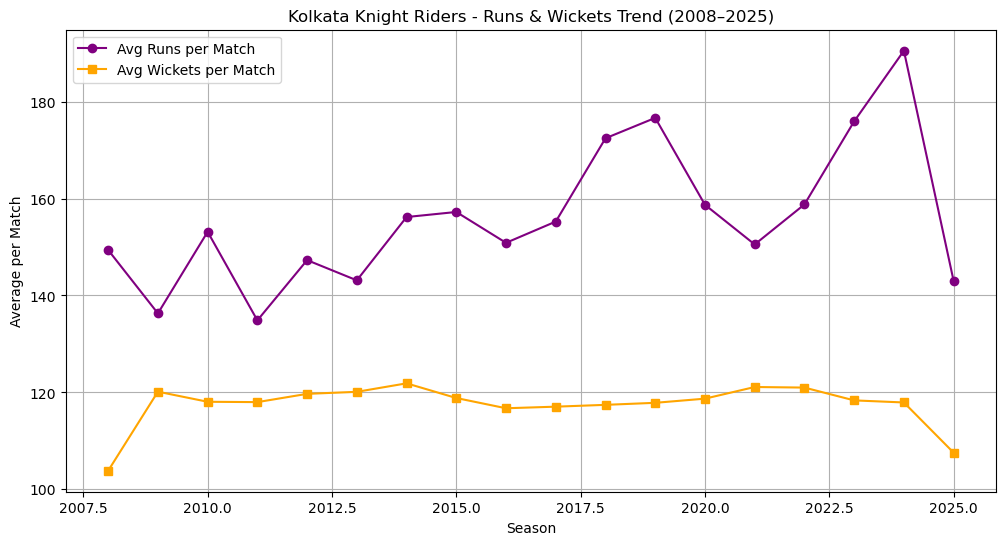

In [41]:
import matplotlib.pyplot as plt

# Pick a few popular teams for clarity
teams_to_plot = ['Mumbai Indians','Chennai Super Kings','Royal Challengers Bangalore','Kolkata Knight Riders']

for team in teams_to_plot:
    subset = team_summary[team_summary['team_batting'] == team]
    
    plt.figure(figsize=(12,6))
    plt.plot(subset['season_id'], subset['avg_runs_per_match'], marker='o', color='purple', label='Avg Runs per Match')
    plt.plot(subset['season_id'], subset['avg_wickets_per_match'], marker='s', color='orange', label='Avg Wickets per Match')
    
    plt.title(f"{team} - Runs & Wickets Trend (2008–2025)")
    plt.xlabel("Season")
    plt.ylabel("Average per Match")
    plt.legend()
    plt.grid(True)
    plt.show()


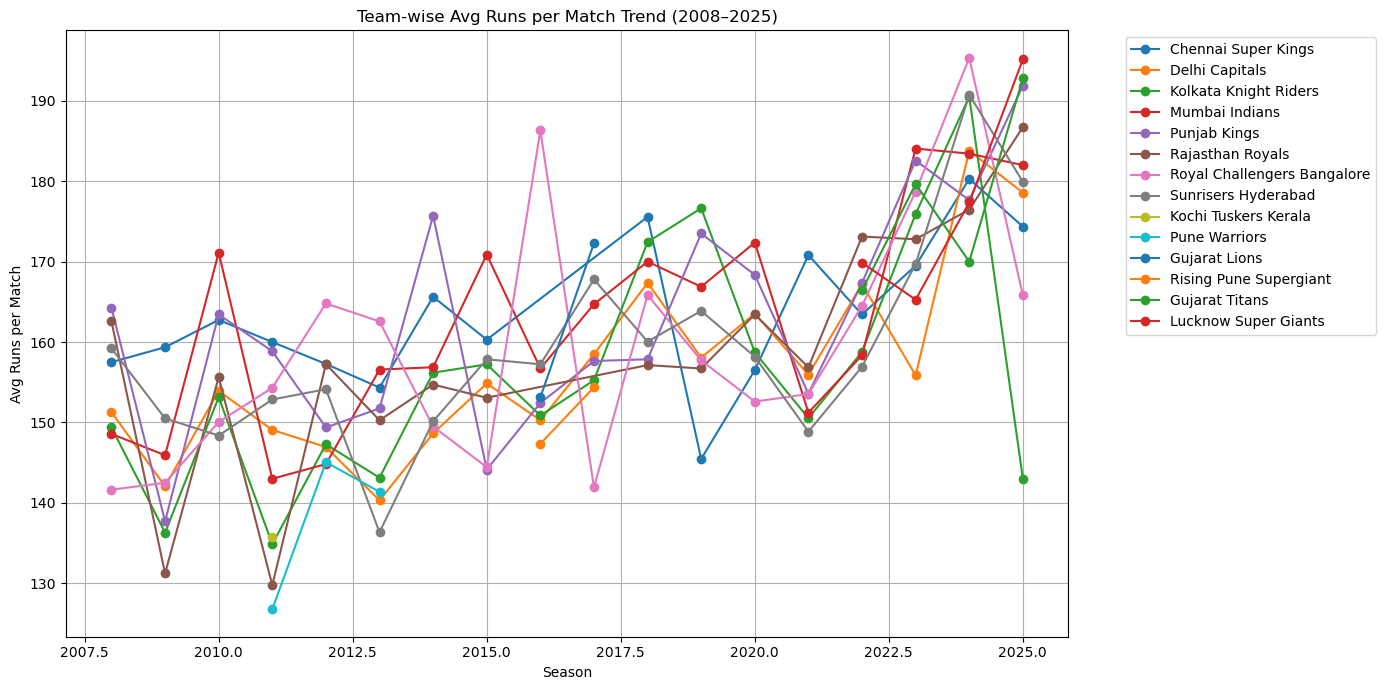

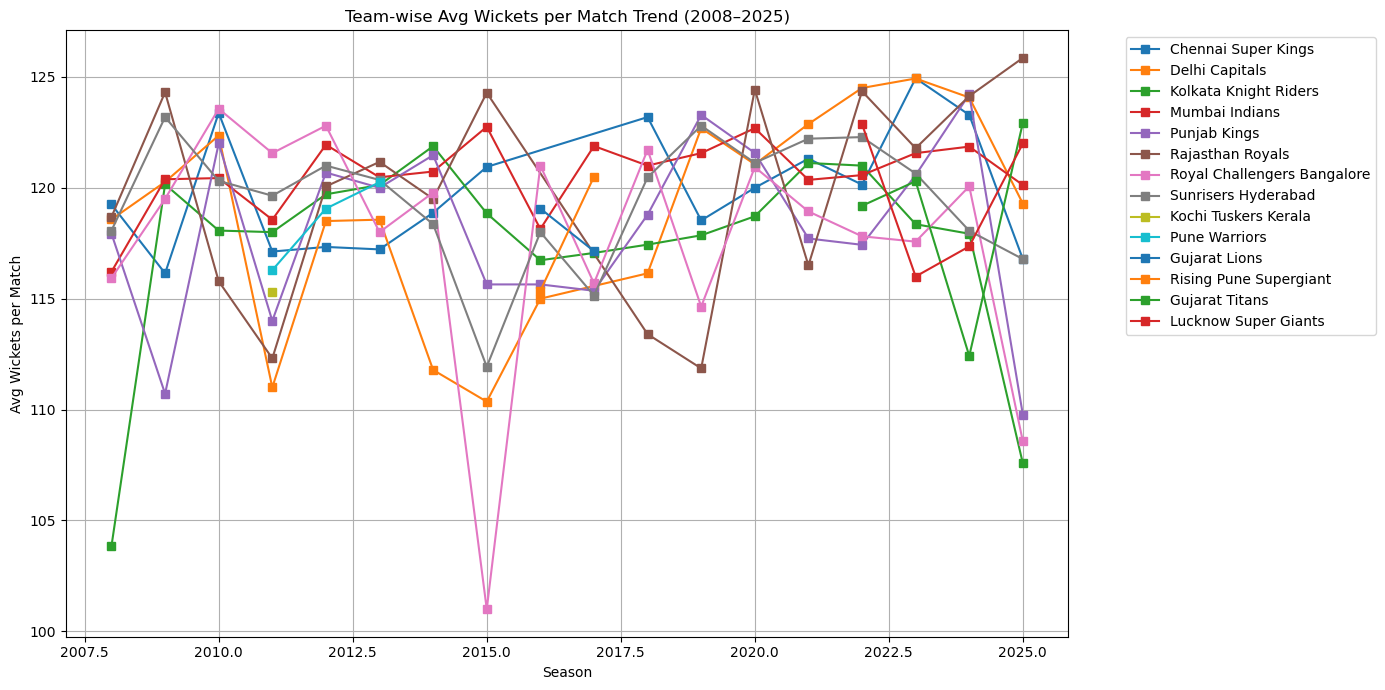

In [42]:
import matplotlib.pyplot as plt

# Get list of all teams
teams = team_summary['team_batting'].unique()

# Runs trend for all teams
plt.figure(figsize=(14,7))
for team in teams:
    subset = team_summary[team_summary['team_batting'] == team]
    plt.plot(subset['season_id'], subset['avg_runs_per_match'], marker='o', label=team)

plt.title("Team-wise Avg Runs per Match Trend (2008–2025)")
plt.xlabel("Season")
plt.ylabel("Avg Runs per Match")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Wickets trend for all teams
plt.figure(figsize=(14,7))
for team in teams:
    subset = team_summary[team_summary['team_batting'] == team]
    plt.plot(subset['season_id'], subset['avg_wickets_per_match'], marker='s', label=team)

plt.title("Team-wise Avg Wickets per Match Trend (2008–2025)")
plt.xlabel("Season")
plt.ylabel("Avg Wickets per Match")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Interactive Dashboard

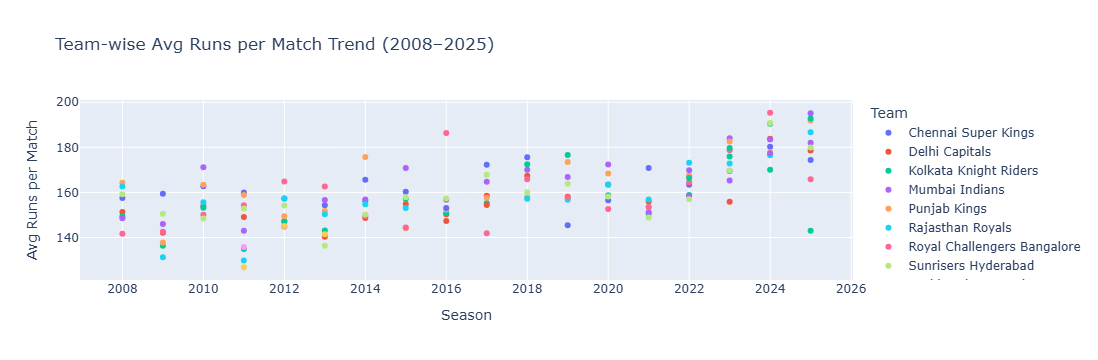

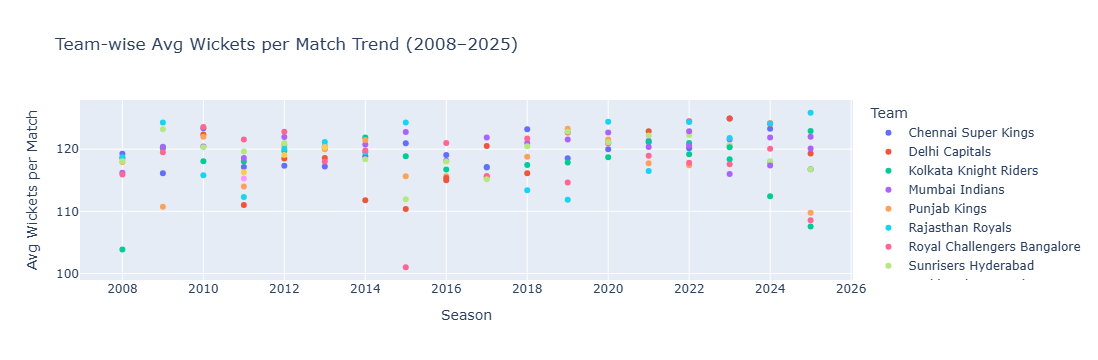

In [43]:
# Runs trend for all teams
fig_runs = px.scatter(
    team_summary,
    x="season_id",
    y="avg_runs_per_match",
    color="team_batting",
    title="Team-wise Avg Runs per Match Trend (2008–2025)",
    labels={"season_id":"Season","avg_runs_per_match":"Avg Runs per Match"}
)
fig_runs.update_layout(legend_title_text="Team")
fig_runs.show()

# Wickets trend for all teams
fig_wickets = px.scatter(
    team_summary,
    x="season_id",
    y="avg_wickets_per_match",
    color="team_batting",
    title="Team-wise Avg Wickets per Match Trend (2008–2025)",
    labels={"season_id":"Season","avg_wickets_per_match":"Avg Wickets per Match"}
)
fig_wickets.update_layout(legend_title_text="Team")
fig_wickets.show()

Averages of eras

In [44]:
# Combine seasonal averages into one DataFrame
import pandas as pd

# Correct way: assign directly into a DataFrame
season_summary['avg_runs_per_match'] = season_summary['runs_scored'] / season_summary['match_id']
season_summary['avg_wickets_per_match'] = season_summary['wickets'] / season_summary['match_id']

avg_runs_per_match = pd.Series(season_summary['runs_scored'] / season_summary['match_id'], name="avg_runs_per_match")
avg_wickets_per_match = pd.Series(season_summary['wickets'] / season_summary['match_id'], name="avg_wickets_per_match")

era_df = pd.concat(
    [avg_runs_per_match, avg_wickets_per_match],
    axis=1
).reset_index().rename(columns={"season_id":"season"})

def assign_era(season):
    if 2008 <= season <= 2012:
        return "2008–2012"
    elif 2013 <= season <= 2017:
        return "2013–2017"
    elif 2018 <= season <= 2020:
        return "2018–2020"
    elif 2021 <= season <= 2025:
        return "2021–2025"
    else:
        return "Other"

season_summary['era'] = season_summary['season_id'].apply(assign_era)


era_df["era"] = era_df.index.map(assign_era)

# Aggregate by era
era_summary = season_summary.groupby("era").agg({
    "runs_scored":"sum",
    "wickets":"sum",
    "match_id":"sum"
}).reset_index()

# Calculate averages
era_summary['avg_runs_per_match'] = era_summary['runs_scored'] / era_summary['match_id']
era_summary['avg_wickets_per_match'] = era_summary['wickets'] / era_summary['match_id']


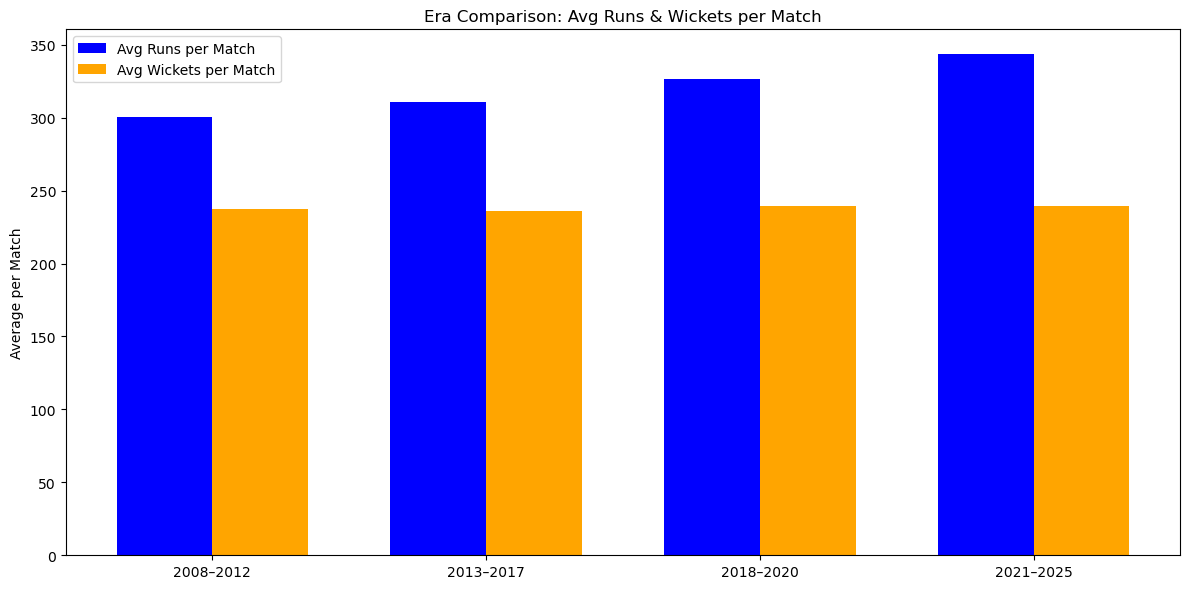

In [45]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(era_summary['era']))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width/2, era_summary['avg_runs_per_match'], width, label='Avg Runs per Match', color='blue')
ax.bar(x + width/2, era_summary['avg_wickets_per_match'], width, label='Avg Wickets per Match', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(era_summary['era'])
ax.set_ylabel("Average per Match")
ax.set_title("Era Comparison: Avg Runs & Wickets per Match")
ax.legend()
plt.tight_layout()
plt.show()